In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df = pd.read_csv("data.csv",encoding="latin1")--Handle western characters better but not emojis or other unicode symbols

# df = pd.read_csv("data.csv",encoding="cp1252")--Handle western characters better but not emojis or other unicode symbols

# df = pd.read_csv("data.csv",encoding="utf-8")--it is flexible but strict,if it doesn't understand byte it raises an error

#prakash #updates

df = pd.read_csv("data.csv",encoding="cp1252")  # ---it is best and accept everything
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-11 12:50,4.15,12680.0,France


In [3]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
df=df[  (df["CustomerID"].notnull()       &      (df["Quantity"]>0))   ]
df["Totalprice"]=df["Quantity"]*df["UnitPrice"]
df

C:\Users\user\AppData\Local\Temp\ipykernel_9932\2239431422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Totalprice"]=df["Quantity"]*df["UnitPrice"]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12-09-11 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12-09-11 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-11 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-11 12:50,4.15,12680.0,France,16.60


In [7]:
df.shape

(397924, 9)

In [8]:
import string
def clean_text(text):
    text=text.lower()                                             # each & every step needs means, need to stored that
    text=text.translate(str.maketrans("","",string.punctuation))
    return text

df["Description"]=df["Description"].apply(clean_text)



df_rfm=df.copy()              # if i need rfm ,it wont affect description duplicates

desc_df=df[["Description","StockCode"]].dropna()        # if i use single its like variable 
desc_df = desc_df.drop_duplicates(subset="Description")                 #  if i use double its like desc_df["Description"]
desc_df = desc_df.drop_duplicates(subset='StockCode')
# ----> df_final=pd.DataFrame(desc_df,columns=["Description"])

#------> df_final


C:\Users\user\AppData\Local\Temp\ipykernel_9932\2841919607.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Description"]=df["Description"].apply(clean_text)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
tf_idf=TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')#  Use max_df and min_df in TfidfVectorizer() to remove overly common/rare words.
ti=tf_idf.fit_transform(desc_df["Description"])   # df["Description"]
print(ti)
print(ti.shape)

#--->  min_df=5: Ignore terms that appear in fewer than 5 documents.


#----->  max_df=0.8: Ignore terms that appear in more than 80% of documents

  (np.int32(0), np.int32(598))	0.43926537565592677
  (np.int32(0), np.int32(275))	0.4668284897811224
  (np.int32(0), np.int32(277))	0.3834052038575865
  (np.int32(0), np.int32(563))	0.4840883013490679
  (np.int32(0), np.int32(282))	0.4558245901993775
  (np.int32(1), np.int32(598))	0.4924363468950543
  (np.int32(1), np.int32(353))	0.5109999751005597
  (np.int32(1), np.int32(325))	0.7045462864169261
  (np.int32(2), np.int32(163))	0.43579271070401326
  (np.int32(2), np.int32(278))	0.4696803964590153
  (np.int32(2), np.int32(144))	0.5703892182061818
  (np.int32(2), np.int32(274))	0.5139466686665952
  (np.int32(3), np.int32(319))	0.4630417800972147
  (np.int32(3), np.int32(586))	0.38801467041770465
  (np.int32(3), np.int32(227))	0.44977657439420043
  (np.int32(3), np.int32(290))	0.38801467041770465
  (np.int32(3), np.int32(596))	0.38801467041770465
  (np.int32(3), np.int32(76))	0.36280461633300826
  (np.int32(4), np.int32(598))	0.6218350102499005
  (np.int32(4), np.int32(277))	0.54275795927

In [10]:
# No need to use scaling 
# In KMeans, scaling is must but when we use TF-IDF -- at the time no need for scaling
# only one scaling === TF-IDF anyone

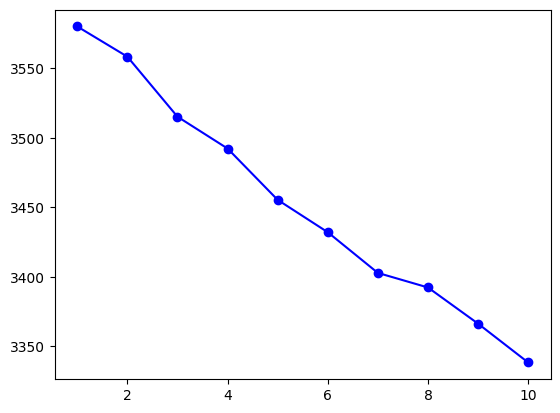

In [11]:
from sklearn.cluster import KMeans

list=range(1,11)
inertia=[]

for i in list:
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(ti)
    inertia.append(model.inertia_)
plt.plot(list,inertia,c="blue",marker="o")
plt.show()

In [12]:
print("Best k point is likely 3 or 4")
print("I choose K===4")

Best k point is likely 3 or 4
I choose K===4


In [13]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=5,random_state=42)
desc_df["Cluster"]=model.fit_predict(ti)                              # fit_predict and labels are the same cluster answer

In [14]:
print(model.inertia_)


3455.3498590294002


In [15]:
print(model.labels_)    # ------> we need to give name here also fine------> df_final["Cluster"] 


[1 3 3 ... 3 2 3]


In [16]:
print("clusters",model.cluster_centers_)

clusters [[0.         0.         0.         ... 0.         0.00963678 0.        ]
 [0.         0.         0.         ... 0.00484968 0.00235812 0.03272146]
 [0.         0.00753293 0.         ... 0.         0.00240547 0.        ]
 [0.00126392 0.00511217 0.         ... 0.00313761 0.00271174 0.00545522]
 [0.01075728 0.02813496 0.01654503 ... 0.         0.         0.        ]]


In [17]:
desc_df


,Description,StockCode,Cluster
0,white hanging heart tlight holder,85123A,1
1,white metal lantern,71053,3
2,cream cupid hearts coat hanger,84406B,3
3,knitted union flag hot water bottle,84029G,3
4,red woolly hottie white heart,84029E,3
...,...,...,...
527065,letter u bling key ring,90214U,3
527067,letter w bling key ring,90214W,3
527069,letter z bling key ring,90214Z,3
530382,pink crystal skull phone charm,90089,2


[[ 0.0134326   0.06187924  0.02795149 ... -0.01880074 -0.00750118
  -0.06656749]
 [-0.00221897  0.00014138  0.00163913 ... -0.00580885 -0.00152575
  -0.06053035]]
                                Description StockCode  Cluster         x  \
0         white hanging heart tlight holder    85123A        1 -0.452745   
1                       white metal lantern     71053        3 -0.185087   
2            cream cupid hearts coat hanger    84406B        3  0.005594   
3       knitted union flag hot water bottle    84029G        3  0.001250   
4             red woolly hottie white heart    84029E        3 -0.173651   
...                                     ...       ...      ...       ...   
527065              letter u bling key ring    90214U        3  0.007960   
527067              letter w bling key ring    90214W        3  0.007960   
527069              letter z bling key ring    90214Z        3  0.007960   
530382       pink crystal skull phone charm     90089        2 -0.016404   
5

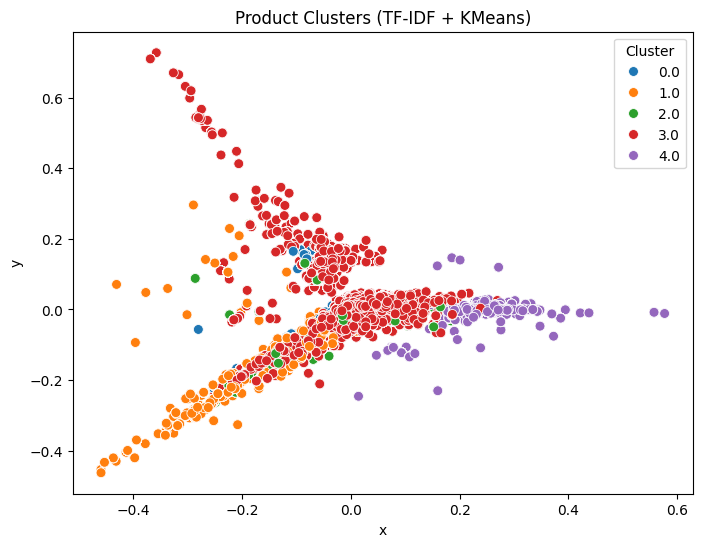

In [18]:
# Visualization :--

from sklearn.decomposition import PCA

pca=PCA(n_components=2)
final=pca.fit_transform(ti)         #------->    # it will give two columns


print(pca.components_)

desc_df["x"]=final[:,0]
desc_df["y"]=final[:,1]
print(desc_df)


# Merging Two dataframes for product similarity

df_final=pd.merge(df,desc_df,on="StockCode",how="left")
print(df_final.shape)# must be same ---> df.shape





plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_final, x='x', y='y', hue='Cluster', palette='tab10', s=50)
plt.title("Product Clusters (TF-IDF + KMeans)")
plt.show()


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                                Description StockCode  Cluster         x  \
0         white hanging heart tlight holder    85123A        1 -0.452745   
1                       white metal lantern     71053        3 -0.185087   
2            cream cupid hearts coat hanger    84406B        3  0.005594   
3       knitted union flag hot water bottle    84029G        3  0.001250   
4             red woolly hottie white heart    84029E        3 -0.173651   
...                                     ...       ...      ...       ...   
527065              letter u bling key ring    90214U        3  0.007960   
527067              letter w bling key ring    90214W        3  0.007960   
527069              letter z bling key ring    90214Z        3  0.007960   
530382       pink crystal skull phone charm     90089        2 -0.016404   
540421           paper craft  little birdie     23843        3  0.033192   

               y  
0      -0.433361  
1       0.240189  
2       0.008522  
3       0.0

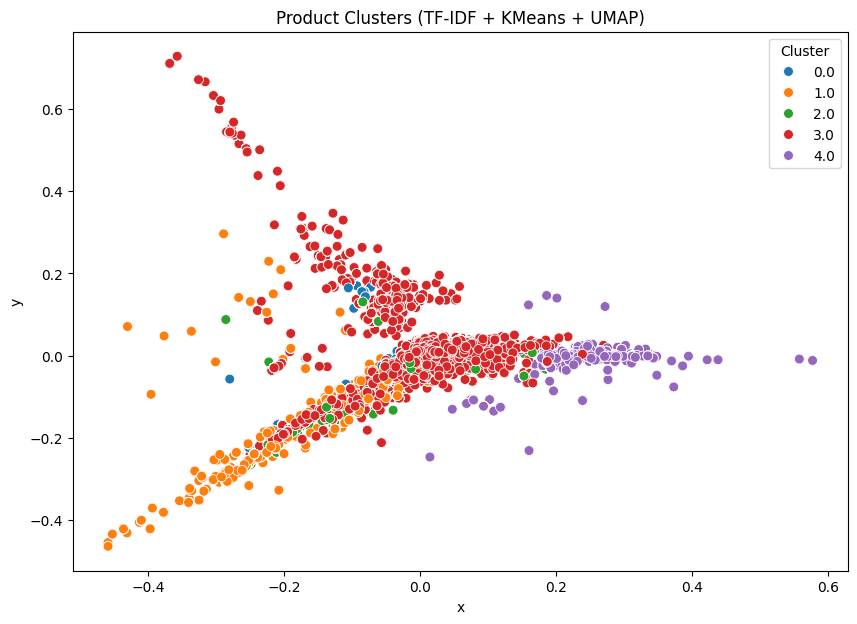

In [20]:
from umap.umap_ import UMAP

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

umap_model = UMAP(n_components=2, random_state=42)
umap_coords = umap_model.fit_transform(ti)



desc_df["x"]=final[:,0]
desc_df["y"]=final[:,1]
print(desc_df)


# Merging Two dataframes for product similarity

df_final=pd.merge(df,desc_df,on="StockCode",how="left")
print(df_final.shape)# must be same ---> df.shape

# Also make sure you have your cluster labels added:
# Example if you did clustering like this:
# kmeans = KMeans(n_clusters=5, random_state=42)
# labels = kmeans.fit_predict(ti)
# df_final["Cluster"] = labels

# Scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='x', y='y', hue='Cluster', palette='tab10', s=50)
plt.title("Product Clusters (TF-IDF + KMeans + UMAP)")
plt.show()



In [ ]:
#  Analyze which customers buy from which product clusters


df_final.groupby(['CustomerID', 'Cluster'])['Totalprice'].sum().unstack(fill_value=0)


#--->Customer 12346 bought only from Cluster 4 and spent ₹77,183.60 — likely loyal to one product category.

#--->Customer 12347 purchased from all clusters except Cluster 0, with highest spend in Cluster 4.


Cluster,0.0,1.0,2.0,3.0,4.0
CustomerID,,,,,
12346.0,0.0,0.00,0.00,77183.60,0.00
12347.0,0.0,91.80,255.50,3451.70,511.00
12348.0,0.0,0.00,63.60,1542.64,191.00
12349.0,0.0,34.80,37.50,1440.38,244.87
12350.0,0.0,0.00,0.00,334.40,0.00
...,...,...,...,...,...
18280.0,0.0,0.00,0.00,162.90,17.70
18281.0,0.0,0.00,0.00,46.92,33.90
18282.0,0.0,0.00,13.00,158.41,6.64


In [ ]:
df_final

,InvoiceNo,StockCode,Description_x,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Totalprice,Description_y,Cluster,x,y
0,536365,85123A,white hanging heart tlight holder,6,12-01-10 08:26,2.55,17850.0,United Kingdom,15.30,white hanging heart tlight holder,1.0,-0.452745,-0.433361
1,536365,71053,white metal lantern,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34,white metal lantern,3.0,-0.185087,0.240189
2,536365,84406B,cream cupid hearts coat hanger,8,12-01-10 08:26,2.75,17850.0,United Kingdom,22.00,cream cupid hearts coat hanger,3.0,0.005594,0.008522
3,536365,84029G,knitted union flag hot water bottle,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34,knitted union flag hot water bottle,3.0,0.001250,0.015151
4,536365,84029E,red woolly hottie white heart,6,12-01-10 08:26,3.39,17850.0,United Kingdom,20.34,red woolly hottie white heart,3.0,-0.173651,-0.202886
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397919,581587,22613,pack of 20 spaceboy napkins,12,12-09-11 12:50,0.85,12680.0,France,10.20,pack of 20 spaceboy napkins,3.0,0.046955,0.011379
397920,581587,22899,childrens apron dolly girl,6,12-09-11 12:50,2.10,12680.0,France,12.60,childrens apron dolly girl,3.0,0.041327,0.019564
397921,581587,23254,childrens cutlery dolly girl,4,12-09-11 12:50,4.15,12680.0,France,16.60,childrens cutlery dolly girl,3.0,0.067217,0.021970
397922,581587,23255,childrens cutlery circus parade,4,12-09-11 12:50,4.15,12680.0,France,16.60,childrens cutlery circus parade,3.0,0.047007,0.014183
